In [286]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [287]:
!pwd

/content


In [288]:
!ls /content/drive/MyDrive/My_Portfolio/UK_economy/earnings.xls

/content/drive/MyDrive/My_Portfolio/UK_economy/earnings.xls


In [289]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Data Ingestion

##The earnings dataset

In [290]:
#Create the excel file as an object
earnings_file = pd.ExcelFile("/content/drive/MyDrive/My_Portfolio/UK_economy/earnings.xls")

#Get all the sheet names
sheets_earnings = earnings_file.sheet_names
print(sheets_earnings)

['Introduction', '1. AWE Total Pay', '2. AWE Bonus Pay', '3. AWE Regular Pay', '4. AWE Total Pay Index', '5. AWE Regular Pay Index', '6. Real AWE', 'Sampling Variability']


In [291]:
#I am going to use only the data in the sheet AWE Total Pay
earnings = pd.read_excel("/content/drive/MyDrive/My_Portfolio/UK_economy/earnings.xls", sheet_name='1. AWE Total Pay', header=None)
earnings.head(10)

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,"EARN01 Average Weekly Earnings - total pay, Gr...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Date of this publication: 16 September 2025,NaN,NaN,NaN,NaN,NaN,Date of next publication: 14 October 2025,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Inquiries: Email:,NaN,earnings@ons.gov.uk,NaN,NaN,NaN,Tel: 01633 456120,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Standard Industrial Classification (2007),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Whole Economy,NaN,NaN,Private sector3 4 5 6,NaN,NaN,Public sector3 4 5 6,NaN,NaN,...,NaN,"Manufacturing, SIC 2007 section C",NaN,NaN,"Construction, SIC 2007 section F",NaN,NaN,"Wholesaling, retailing, hotels & restaurants, ...",NaN,NaN
5,NaN,Weekly Earnings (£),% changes year on year,NaN,Weekly Earnings (£),% changes year on year,NaN,Weekly Earnings (£),% changes year on year,NaN,...,NaN,Weekly Earnings (£),% changes year on year,NaN,Weekly Earnings (£),% changes year on year,NaN,Weekly Earnings (£),% changes year on year,NaN
6,NaN,NaN,Single month,3 month average 2,NaN,Single month,3 month average 2,NaN,Single month,3 month average 2,...,3 month average 2,NaN,Single month,3 month average 2,NaN,Single month,3 month average 2,NaN,Single month,3 month average 2
7,NaN,KAB9,KAC2,KAC3,KAC4,KAC5,KAC6,KAC7,KAC8,KAC9,...,KAE2,K5CA,K5CB,K5CC,K5CD,K5CE,K5CF,K5CG,K5CH,K5CI
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2000-01-01 00:00:00,304.722925,NaN,NaN,304.95015,NaN,NaN,313.290541,NaN,NaN,...,NaN,362.917902,NaN,NaN,356.442732,NaN,NaN,208.694425,NaN,NaN


In [292]:
#Now I need to define a header which will need to come from rows 4 and 5
new_header_earnings= earnings.iloc[4].astype(str) + '_' + earnings.iloc[5].astype(str)
earnings = earnings[6:]
earnings.columns = new_header_earnings
earnings.head(10)

,nan_nan,Whole Economy_Weekly Earnings (£),nan_% changes year on year,nan_nan,Private sector3 4 5 6_Weekly Earnings (£),nan_% changes year on year,nan_nan,Public sector3 4 5 6_Weekly Earnings (£),nan_% changes year on year,nan_nan,...,nan_nan,"Manufacturing, SIC 2007 section C _Weekly Earnings (£)",nan_% changes year on year,nan_nan,"Construction, SIC 2007 section F_Weekly Earnings (£)",nan_% changes year on year,nan_nan,"Wholesaling, retailing, hotels & restaurants, SIC 2007 sections G & I _Weekly Earnings (£)",nan_% changes year on year,nan_nan
6,NaN,NaN,Single month,3 month average 2,NaN,Single month,3 month average 2,NaN,Single month,3 month average 2,...,3 month average 2,NaN,Single month,3 month average 2,NaN,Single month,3 month average 2,NaN,Single month,3 month average 2
7,NaN,KAB9,KAC2,KAC3,KAC4,KAC5,KAC6,KAC7,KAC8,KAC9,...,KAE2,K5CA,K5CB,K5CC,K5CD,K5CE,K5CF,K5CG,K5CH,K5CI
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2000-01-01 00:00:00,304.722925,NaN,NaN,304.95015,NaN,NaN,313.290541,NaN,NaN,...,NaN,362.917902,NaN,NaN,356.442732,NaN,NaN,208.694425,NaN,NaN
10,2000-02-01 00:00:00,299.818577,NaN,NaN,296.227753,NaN,NaN,314.924068,NaN,NaN,...,NaN,356.064624,NaN,NaN,362.711122,NaN,NaN,209.186508,NaN,NaN
11,2000-03-01 00:00:00,311.418715,NaN,NaN,308.882042,NaN,NaN,312.309388,NaN,NaN,...,NaN,357.573804,NaN,NaN,358.228229,NaN,NaN,207.995835,NaN,NaN
12,2000-04-01 00:00:00,308.748756,NaN,NaN,308.676043,NaN,NaN,309.39488,NaN,NaN,...,NaN,365.816052,NaN,NaN,360.131416,NaN,NaN,209.351121,NaN,NaN
13,2000-05-01 00:00:00,311.178774,NaN,NaN,311.358409,NaN,NaN,309.917402,NaN,NaN,...,NaN,362.060682,NaN,NaN,363.802803,NaN,NaN,211.405946,NaN,NaN
14,2000-06-01 00:00:00,310.500144,NaN,NaN,309.118333,NaN,NaN,312.124778,NaN,NaN,...,NaN,361.602581,NaN,NaN,367.83133,NaN,NaN,210.727928,NaN,NaN
15,2000-07-01 00:00:00,313.05003,NaN,NaN,313.174447,NaN,NaN,312.126638,NaN,NaN,...,NaN,362.663806,NaN,NaN,368.574056,NaN,NaN,211.393125,NaN,NaN


Now I'll do some cleaning, delete not needed rows and columns, get the right data types and filter only data I want to analyze. For this exercise I'll use the total pay in the whole economy

In [293]:
earnings = earnings.drop([6,7,8])
earnings.columns.values[0]= 'date'
earnings.columns.values[1]= 'weekly_earnings_gbp'
earnings = earnings[['date', 'weekly_earnings_gbp']].reset_index(drop=True)
earnings['date'] = pd.to_datetime(earnings['date'], errors= 'coerce')
#I am going to be analyzing data from the last 20 years
earnings = earnings[earnings['date'] >= '2005-01-01']
earnings = earnings.dropna()

In [294]:
print("the dataset starts from ", earnings['date'].min())
print("the dataset ends at ", earnings['date'].max())

the dataset starts from  2005-01-01 00:00:00
the dataset ends at  2025-07-01 00:00:00


In [295]:

earnings.head(10)

,date,weekly_earnings_gbp
60,2005-01-01,379.071339
61,2005-02-01,370.950899
62,2005-03-01,375.885979
63,2005-04-01,378.563489
64,2005-05-01,379.516459
65,2005-06-01,379.712606
66,2005-07-01,382.673335
67,2005-08-01,386.119892
68,2005-09-01,387.255919
69,2005-10-01,387.773099


##The Disposable income dataset

In [296]:
!ls /content/drive/MyDrive/My_Portfolio/UK_economy/disposable_income_per_head.xls

/content/drive/MyDrive/My_Portfolio/UK_economy/disposable_income_per_head.xls


In [297]:
income_file = pd.ExcelFile("/content/drive/MyDrive/My_Portfolio/UK_economy/disposable_income_per_head.xls")
sheets_income = income_file.sheet_names
print(sheets_income)

['data']


In [298]:
income = pd.read_excel("/content/drive/MyDrive/My_Portfolio/UK_economy/disposable_income_per_head.xls", sheet_name='data')
income.head(10)

,Title,Households: Gross disposable income per head: Current price £: Seasonally adjusted
0,CDID,CRXS
1,Source dataset ID,UKEA
2,PreUnit,NaN
3,Unit,NaN
4,Release date,30-06-2025
5,Next release,30 September 2025
6,Important notes,NaN
7,1955,248
8,1956,265
9,1957,277


In [299]:
income_new_header = ['year', 'income_per_head']
income = income[7:]
income.columns = income_new_header
income.head(10)

,year,income_per_head
7,1955,248
8,1956,265
9,1957,277
10,1958,290
11,1959,306
12,1960,328
13,1961,349
14,1962,364
15,1963,383
16,1964,412


In [300]:
income['year'].unique()

array(['1955', '1956', '1957', '1958', '1959', '1960', '1961', '1962',
       '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970',
       '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978',
       '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994',
       '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002',
       '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
       '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018',
       '2019', '2020', '2021', '2022', '2023', '2024', '1955 Q1',
       '1955 Q2', '1955 Q3', '1955 Q4', '1956 Q1', '1956 Q2', '1956 Q3',
       '1956 Q4', '1957 Q1', '1957 Q2', '1957 Q3', '1957 Q4', '1958 Q1',
       '1958 Q2', '1958 Q3', '1958 Q4', '1959 Q1', '1959 Q2', '1959 Q3',
       '1959 Q4', '1960 Q1', '1960 Q2', '1960 Q3', '1960 Q4', '1961 Q1',
       '1961 Q2', '1961 Q3', '1961 Q4', '1962 Q1', '1962 Q2', '1962 Q3',
 

In [301]:
income['year'] = income['year'].apply(lambda x: int(x) if x.isnumeric() else np.nan)
income = income.dropna()
income = income[income['year']>=2005]
income

,year,income_per_head
57,2005.0,14038
58,2006.0,14618
59,2007.0,15297
60,2008.0,15695
61,2009.0,15963
62,2010.0,16111
63,2011.0,16270
64,2012.0,16870
65,2013.0,17506
66,2014.0,18060


##The Rent dataset

In [302]:
!ls /content/drive/MyDrive/My_Portfolio/UK_economy/rent.xlsx

/content/drive/MyDrive/My_Portfolio/UK_economy/rent.xlsx


In [303]:
#again we first create the file as an object to see the sheets contained
rent_file = pd.ExcelFile("/content/drive/MyDrive/My_Portfolio/UK_economy/rent.xlsx")
sheets_rent = rent_file.sheet_names
print(sheets_rent)

['Cover sheet', 'Contents', 'Notes', 'Table 1', 'Table 2', 'Table 3']


In [304]:
#After exploring the different sheets I'm going to use the Table 3 which contains the rent in gbp so it makes it easier to compare against the earnings values we already have
#
rent = pd.read_excel("/content/drive/MyDrive/My_Portfolio/UK_economy/rent.xlsx", sheet_name='Table 3', header=2)
rent = rent.drop([0])
rent = rent.rename(columns={'Time period and Region Code':'date'})
rent['date'] = pd.to_datetime(rent['date'], errors= 'coerce')
rent = rent[rent['date'] >= '2005-01-01']
rent = rent.dropna()
rent = rent[['date', 'Great Britain', 'England', 'London']]
rent = rent.rename(columns={'Great Britain': 'Great_Britain'})
rent = rent.replace('[x]', np.nan )
rent.head(10)

/tmp/ipython-input-885704033.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rent = rent.replace('[x]', np.nan )


,date,Great_Britain,England,London
1,2005-01-01,NaN,775,1193
2,2005-02-01,NaN,775,1192
3,2005-03-01,NaN,776,1193
4,2005-04-01,NaN,777,1194
5,2005-05-01,NaN,779,1194
6,2005-06-01,NaN,780,1194
7,2005-07-01,NaN,782,1196
8,2005-08-01,NaN,784,1200
9,2005-09-01,NaN,786,1203
10,2005-10-01,NaN,787,1204


In [305]:
print("there is ", rent['Great_Britain'].isna().sum(), " missing values in the Great Britain column")
print("there is ", rent['England'].isna().sum(), " missing values in the England column")
print("there is ", rent['London'].isna().sum(), " missing values in the London column")

there is  72  missing values in the Great Britain column
there is  0  missing values in the England column
there is  0  missing values in the London column


In [306]:
rent.describe()

,date,Great_Britain,England,London
count,242,170.000000,242.000000,242.000000
mean,2015-01-15 15:46:06.942148864,1008.664706,978.921488,1568.995868
min,2005-01-01 00:00:00,843.000000,775.000000,1192.000000
25%,2010-01-08 18:00:00,909.250000,863.000000,1347.250000
50%,2015-01-16 12:00:00,995.000000,951.000000,1581.500000
75%,2020-01-24 06:00:00,1049.250000,1066.500000,1715.500000
max,2025-02-01 00:00:00,1338.000000,1381.000000,2235.000000
std,NaN,119.594777,142.726118,246.173479


In [307]:
#Great Britain and England have similar tendencies, and since Great Britain is missing some values I'm going to use the same as England's
rent['Great_Britain'] = rent['Great_Britain'].fillna(rent['England'])
rent

,date,Great_Britain,England,London
1,2005-01-01,775.0,775,1193
2,2005-02-01,775.0,775,1192
3,2005-03-01,776.0,776,1193
4,2005-04-01,777.0,777,1194
5,2005-05-01,779.0,779,1194
...,...,...,...,...
238,2024-10-01,1306.0,1348,2172
239,2024-11-01,1320.0,1362,2209
240,2024-12-01,1327.0,1370,2221
241,2025-01-01,1333.0,1375,2229


In [308]:
#There would be some months missing to compare against earnings
print("the rent dataset starts from ", rent['date'].min())
print("the rent dataset ends at ", rent['date'].max())

the rent dataset starts from  2005-01-01 00:00:00
the rent dataset ends at  2025-02-01 00:00:00


##The consumption dataset

In [309]:
!ls /content/drive/MyDrive/My_Portfolio/UK_economy/consumer_trends.xlsx

/content/drive/MyDrive/My_Portfolio/UK_economy/consumer_trends.xlsx


In [310]:
consumption_file = pd.ExcelFile("/content/drive/MyDrive/My_Portfolio/UK_economy/consumer_trends.xlsx")
sheets_consumption = consumption_file.sheet_names
print(sheets_consumption)


['Table_of_contents', 'Cover_sheet', 'Impact_of_Covid-19', 'Notes', '0CS', '01CS', '02CS', '03CS', '04CS', '05CS', '06CS', '07CS', '08CS', '09CS', '10CS', '11CS', '12CS', 'TOURCS', '0GSCS', 'TGCS', 'DGCS', 'SDGCS', 'NDGCS', 'SERCS']


In [311]:
consumption = pd.read_excel("/content/drive/MyDrive/My_Portfolio/UK_economy/consumer_trends.xlsx", sheet_name='0CS', header=5)
consumption = consumption.drop([0,1])

In [312]:
consumption.columns.to_list()

['Time period and codes',
 'Total expenditure',
 'Net tourism',
 'Total domestic expenditure',
 'Food and drink',
 'Alcohol, tobacco and narcotics',
 'Clothing and footwear',
 'Housing',
 'Furnishings, household equipment and routine maintenance of the house',
 'Health',
 'Transport',
 'Communication',
 'Recreation and culture',
 'Education',
 'Restaurants and hotels',
 'Miscellaneous']

In [313]:

# The same sheet contains 2 different tables, the second one is the quarterly data, I am going to keep only annual
consumption = consumption.iloc[:28]
consumption = consumption.rename(columns = {
    'Time period and codes': 'year',
  'Total expenditure': 'total_expenditure',
 'Net tourism': 'net_tourism',
 'Total domestic expenditure': 'total_domestic_expenditiure',
 'Food and drink':'food_and_drink',
 'Alcohol, tobacco and narcotics' : 'alcohol_tobacco_narcotics',
 'Clothing and footwear': 'clothing_and_footwear',
 'Housing': 'housing',
 'Furnishings, household equipment and routine maintenance of the house' : 'furnishings_household_equipment_maintenance',
 'Health': 'health',
 'Transport': 'transport',
 'Communication': 'communication',
 'Recreation and culture':'recreation_and_culture',
 'Education':'education',
 'Restaurants and hotels':'restaurants_hotels',
 'Miscellaneous': 'miscellaneous'})
consumption['year'] = consumption['year'].astype(int)
consumption = consumption[consumption['year'] >= 2005]


In [314]:
consumption

,year,total_expenditure,net_tourism,total_domestic_expenditiure,food_and_drink,alcohol_tobacco_narcotics,clothing_and_footwear,housing,furnishings_household_equipment_maintenance,health,transport,communication,recreation_and_culture,education,restaurants_hotels,miscellaneous
10,2005,874142,11894,862248,67822,33592,43268,218365,43497,13051,121018,21856,90081,9112,88820,111766
11,2006,907535,11509,896026,70234,35103,45108,231730,45121,11360,124001,22432,93765,9984,91227,115961
12,2007,951491,12642,938849,73367,33917,46219,241123,47115,15758,132340,22725,96568,11527,94753,123437
13,2008,981077,14244,966833,77885,35307,48017,254765,44904,15666,136070,22746,97963,12322,95885,125303
14,2009,957048,11406,945642,80070,37995,48357,258953,43049,15461,127944,22002,95214,13670,90493,112434
15,2010,987020,12208,974812,81424,37317,49509,265760,45750,16648,135908,23463,98159,14575,94553,111746
16,2011,1022611,10388,1012223,87431,41683,51892,270699,46213,17542,143421,24600,99838,15509,100088,113307
17,2012,1058134,9211,1048923,89867,41417,53624,286319,47129,19583,147664,25767,98841,16920,104969,116823
18,2013,1112232,10110,1102122,93003,42660,57973,299288,48101,23739,156437,25546,103876,19011,110703,121785
19,2014,1158972,10625,1148347,94365,41351,58704,307015,50509,24420,162159,24549,107783,21540,116186,139766


The data we have ingested so far is at household level, the consumption data is total expenditure by sector, so we will use additional data to estimate the expenditure per household in the UK

##UK Households

###UK population

In [315]:
!ls /content/drive/MyDrive/My_Portfolio/UK_economy/uk_population.xls

/content/drive/MyDrive/My_Portfolio/UK_economy/uk_population.xls


In [316]:
population_file = pd.ExcelFile("/content/drive/MyDrive/My_Portfolio/UK_economy/uk_population.xls")
sheets_population = population_file.sheet_names
print(sheets_population)

['data']


In [317]:
population = pd.read_excel("/content/drive/MyDrive/My_Portfolio/UK_economy/uk_population.xls", sheet_name='data', header = 5)
population = population.rename(columns={'Release date':'year', '26-09-2025': 'population'})
population = population[2:]
population['year']= population['year'].astype(int)
population = population[population['year'] >= 2005]

In [318]:
population

,year,population
36,2005,60413300
37,2006,60827000
38,2007,61319100
39,2008,61823800
40,2009,62260500
41,2010,62759500
42,2011,63285100
43,2012,63710500
44,2013,64138200
45,2014,64618700


###UK Household size

In [319]:
!ls /content/drive/MyDrive/My_Portfolio/UK_economy/household_size.xlsx

/content/drive/MyDrive/My_Portfolio/UK_economy/household_size.xlsx


In [320]:
household_file = pd.ExcelFile("/content/drive/MyDrive/My_Portfolio/UK_economy/household_size.xlsx")
sheets_household = household_file.sheet_names
print(sheets_household)

['Cover sheet', 'Notes', 'Statistical robustness', 'Covid-19 and LFS', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [321]:
household_size = pd.read_excel("/content/drive/MyDrive/My_Portfolio/UK_economy/household_size.xlsx", sheet_name='5', header = 11)
household_size.head()

,Number of households (thousands) [note 9],1996 Estimate,1996 CV,1996 CI+/-,1997 Estimate,1997 CV,1997 CI+/-,1998 Estimate,1998 CV,1998 CI+/-,...,2021 CI+/-,2022 Estimate,2022 CV,2022 CI+/-,2023 Estimate,2023 CV,2023 CI+/-,2024 Estimate,2024 CV,2024 CI+/-
0,One person,6608,a,88,6642,a,89,6709,a,90,...,191.0,8346.0,a,205.0,8380.0,a,246.0,8433.0,a,217.0
1,Two people,8094,a,78,8259,a,79,8369,a,82,...,152.0,9804.0,a,162.0,9698.0,a,189.0,9874.0,a,182.0
2,Three people,3918,a,65,3847,a,65,3894,a,67,...,110.0,4288.0,a,118.0,4526.0,a,155.0,4510.0,a,143.0
3,Four people,3469,a,56,3458,a,56,3436,a,57,...,108.0,3998.0,a,114.0,3961.0,a,144.0,3962.0,a,131.0
4,Five people,1186,a,35,1191,a,35,1164,a,36,...,72.0,1239.0,a,78.0,1249.0,a,89.0,1360.0,a,89.0


In [322]:
cols_to_keep = [col for col in household_size.columns if 'households' in col or 'Estimate' in col]
household_size = household_size[cols_to_keep]
household_size = household_size.drop([0,1,2,3,4,5,6,7,8])
household_size = household_size.T.reset_index()
household_size = household_size.rename(columns={'index': 'year', 9: 'average_household_size'})
household_size = household_size.drop([0]).reset_index(drop=True)


In [323]:
household_size['year'] = household_size['year'].apply(lambda x: int(x.split(' ')[0]))
household_size = household_size[household_size['year'] >= 2005]
household_size['average_household_size'] = household_size['average_household_size'].astype(float)
household_size

,year,average_household_size
9,2005,2.36
10,2006,2.36
11,2007,2.36
12,2008,2.36
13,2009,2.36
14,2010,2.36
15,2011,2.36
16,2012,2.36
17,2013,2.37
18,2014,2.38


###Number of households in the UK

In [324]:
uk_households = population.merge(household_size, on ='year')
uk_households['households_per_capita'] = uk_households['population'] / uk_households['average_household_size']
uk_households

,year,population,average_household_size,households_per_capita
0,2005,60413300,2.36,25598855.932203
1,2006,60827000,2.36,25774152.542373
2,2007,61319100,2.36,25982669.491525
3,2008,61823800,2.36,26196525.423729
4,2009,62260500,2.36,26381567.79661
5,2010,62759500,2.36,26593008.474576
6,2011,63285100,2.36,26815720.338983
7,2012,63710500,2.36,26995974.576271
8,2013,64138200,2.37,27062531.64557
9,2014,64618700,2.38,27150714.285714


#Transform data into insights

##Yearly gross earnings

In [325]:
earnings

,date,weekly_earnings_gbp
60,2005-01-01,379.071339
61,2005-02-01,370.950899
62,2005-03-01,375.885979
63,2005-04-01,378.563489
64,2005-05-01,379.516459
...,...,...
302,2025-03-01,725.010479
303,2025-04-01,719.763788
304,2025-05-01,722.569363
305,2025-06-01,724.501564


In [326]:
earnings['monthly_earnings_gbp'] = earnings['weekly_earnings_gbp'] * 4.33
earnings['year'] = earnings['date'].dt.year


In [327]:
gross_earnings_per_person = earnings.groupby('year').agg({'monthly_earnings_gbp': 'sum'}).reset_index()
#I'm going to disregard 2025 as the year hasn't end and I don't have comparison data for expenditure on the year
gross_earnings_per_person = gross_earnings_per_person[gross_earnings_per_person['year'] < 2025]

In [328]:
gross_earnings_per_household = gross_earnings_per_person.merge(household_size[['year', 'average_household_size']], on='year')
gross_earnings_per_household['gross_earnings_per_household'] = gross_earnings_per_household['monthly_earnings_gbp'] * gross_earnings_per_household['average_household_size']
gross_earnings_per_household

,year,monthly_earnings_gbp,average_household_size,gross_earnings_per_household
0,2005,19862.404671,2.36,46875.275024
1,2006,20792.458164,2.36,49070.201268
2,2007,21807.37972,2.36,51465.416139
3,2008,22577.560717,2.36,53283.043292
4,2009,22558.273153,2.36,53237.52464
5,2010,23079.084511,2.36,54466.639446
6,2011,23625.585706,2.36,55756.382266
7,2012,23933.637514,2.36,56483.384532
8,2013,24197.11725,2.37,57347.167883
9,2014,24459.592425,2.38,58213.829972


##disposable income per household

In [329]:
household_size

,year,average_household_size
9,2005,2.36
10,2006,2.36
11,2007,2.36
12,2008,2.36
13,2009,2.36
14,2010,2.36
15,2011,2.36
16,2012,2.36
17,2013,2.37
18,2014,2.38


In [330]:
income_per_household = income.merge(household_size[['year', 'average_household_size']], on='year')
income_per_household['disposable_income_gbp'] = income_per_household['income_per_head'] * income_per_household['average_household_size']
display(income_per_household)

,year,income_per_head,average_household_size,disposable_income_gbp
0,2005.0,14038,2.36,33129.68
1,2006.0,14618,2.36,34498.48
2,2007.0,15297,2.36,36100.92
3,2008.0,15695,2.36,37040.2
4,2009.0,15963,2.36,37672.68
5,2010.0,16111,2.36,38021.96
6,2011.0,16270,2.36,38397.2
7,2012.0,16870,2.36,39813.2
8,2013.0,17506,2.37,41489.22
9,2014.0,18060,2.38,42982.8


##rent

In [331]:
rent

,date,Great_Britain,England,London
1,2005-01-01,775.0,775,1193
2,2005-02-01,775.0,775,1192
3,2005-03-01,776.0,776,1193
4,2005-04-01,777.0,777,1194
5,2005-05-01,779.0,779,1194
...,...,...,...,...
238,2024-10-01,1306.0,1348,2172
239,2024-11-01,1320.0,1362,2209
240,2024-12-01,1327.0,1370,2221
241,2025-01-01,1333.0,1375,2229


In [332]:
rent['year'] = rent['date'].dt.year
rent_year = rent.groupby('year').agg({'Great_Britain': 'sum', 'England': 'sum', 'London': 'sum'}).reset_index()
rent_year = rent_year[rent_year['year']<2025]
rent_year

,year,Great_Britain,England,London
0,2005,9381.0,9381,14377
1,2006,9614.0,9614,14707
2,2007,9870.0,9870,15143
3,2008,10210.0,10210,15833
4,2009,10375.0,10375,16195
5,2010,10302.0,10302,16086
6,2011,10232.0,10545,16676
7,2012,10511.0,10848,17525
8,2013,10734.0,11085,18209
9,2014,10902.0,11261,18621


##consumption per household

In [333]:
consumption_per_household = consumption.merge(uk_households[['year', 'households_per_capita']], on='year')
consumption_per_household['total_expenditure'] = (consumption_per_household['total_expenditure'] *1000000) / consumption_per_household['households_per_capita']
consumption_per_household['net_tourism'] = (consumption_per_household['net_tourism'] *1000000) / consumption_per_household['households_per_capita']
consumption_per_household['total_domestic_expenditiure'] = (consumption_per_household['total_domestic_expenditiure'] *1000000) / consumption_per_household['households_per_capita']
consumption_per_household['food_and_drink'] = (consumption_per_household['food_and_drink'] *1000000) / consumption_per_household['households_per_capita']
consumption_per_household['alcohol_tobacco_narcotics'] = (consumption_per_household['alcohol_tobacco_narcotics'] *1000000) / consumption_per_household['households_per_capita']
consumption_per_household['clothing_and_footwear'] = (consumption_per_household['clothing_and_footwear'] *1000000) / consumption_per_household['households_per_capita']
consumption_per_household['housing'] = (consumption_per_household['housing'] *1000000) / consumption_per_household['households_per_capita']
consumption_per_household['furnishings_household_equipment_maintenance'] = (consumption_per_household['furnishings_household_equipment_maintenance'] *1000000) / consumption_per_household['households_per_capita']
consumption_per_household['health'] = (consumption_per_household['health'] *1000000) / consumption_per_household['households_per_capita']
consumption_per_household['transport'] = (consumption_per_household['transport'] *1000000) / consumption_per_household['households_per_capita']
consumption_per_household['communication'] = (consumption_per_household['communication'] *1000000) / consumption_per_household['households_per_capita']
consumption_per_household['recreation_and_culture'] = (consumption_per_household['recreation_and_culture'] *1000000) / consumption_per_household['households_per_capita']
consumption_per_household['education'] = (consumption_per_household['education'] *1000000) / consumption_per_household['households_per_capita']
consumption_per_household['restaurants_hotels'] = (consumption_per_household['restaurants_hotels'] *1000000) / consumption_per_household['households_per_capita']
consumption_per_household['miscellaneous'] = (consumption_per_household['miscellaneous'] *1000000) / consumption_per_household['households_per_capita']
consumption_per_household

,year,total_expenditure,net_tourism,total_domestic_expenditiure,food_and_drink,alcohol_tobacco_narcotics,clothing_and_footwear,housing,furnishings_household_equipment_maintenance,health,transport,communication,recreation_and_culture,education,restaurants_hotels,miscellaneous,households_per_capita
0,2005,34147.697941,464.630139,33683.067801,2649.415278,1312.246144,1690.231787,8530.264031,1699.177499,509.827472,4727.476897,853.788156,3518.946325,355.953408,3469.686311,4366.054495,25598855.932203
1,2006,35211.051014,446.532625,34764.518388,2724.978053,1361.945846,1750.125438,8990.790274,1750.629819,440.75164,4811.06022,870.329295,3637.946964,387.364822,3539.476219,4499.119799,25774152.542373
2,2007,36620.217192,486.555086,36133.662105,2823.689845,1305.370105,1778.839546,9280.147295,1813.32407,606.481178,5093.395043,874.621447,3716.631196,443.641867,3646.776942,4750.743569,25982669.491525
3,2008,37450.653632,543.736231,36906.917401,2973.104209,1347.774158,1832.953005,9725.144685,1714.120452,598.018239,5194.200292,868.283088,3739.54173,470.367722,3660.218233,4783.191586,26196525.423729
4,2009,36277.146505,432.347315,35844.79919,3035.073602,1440.210085,1832.984316,9815.678962,1631.783233,586.053116,4849.749681,833.991375,3609.110752,518.164808,3430.160053,4261.839208,26381567.79661
5,2010,37115.770521,459.06803,36656.702491,3061.857408,1403.26357,1861.729937,9993.604156,1720.376995,626.029207,5110.666592,882.299572,3691.158151,548.076387,3555.558601,4202.081916,26593008.474576
6,2011,38134.757787,387.384708,37747.373078,3260.438239,1554.424027,1935.133546,10094.787557,1723.354787,654.168517,5348.392592,917.372336,3723.114604,578.354779,3732.437493,4225.394603,26815720.338983
7,2012,39195.991869,341.199017,38854.792852,3328.903713,1534.191695,1986.370222,10605.988652,1745.778796,725.404447,5469.852536,954.475636,3661.323644,626.76011,3888.32045,4327.422952,26995974.576271
8,2013,41098.593974,373.57924,40725.014734,3436.596443,1576.349196,2142.186871,11059.127946,1777.402079,877.19066,5780.575227,943.961945,3838.369646,702.484167,4090.637249,4500.133306,27062531.64557
9,2014,42686.61177,391.334088,42295.277683,3475.599169,1523.017021,2162.153061,11307.805635,1860.319381,899.423851,5972.550051,904.175107,3969.803478,793.349294,4279.298098,5147.783536,27150714.285714


##A unified dataset

In [334]:
consumption_per_household

,year,total_expenditure,net_tourism,total_domestic_expenditiure,food_and_drink,alcohol_tobacco_narcotics,clothing_and_footwear,housing,furnishings_household_equipment_maintenance,health,transport,communication,recreation_and_culture,education,restaurants_hotels,miscellaneous,households_per_capita
0,2005,34147.697941,464.630139,33683.067801,2649.415278,1312.246144,1690.231787,8530.264031,1699.177499,509.827472,4727.476897,853.788156,3518.946325,355.953408,3469.686311,4366.054495,25598855.932203
1,2006,35211.051014,446.532625,34764.518388,2724.978053,1361.945846,1750.125438,8990.790274,1750.629819,440.75164,4811.06022,870.329295,3637.946964,387.364822,3539.476219,4499.119799,25774152.542373
2,2007,36620.217192,486.555086,36133.662105,2823.689845,1305.370105,1778.839546,9280.147295,1813.32407,606.481178,5093.395043,874.621447,3716.631196,443.641867,3646.776942,4750.743569,25982669.491525
3,2008,37450.653632,543.736231,36906.917401,2973.104209,1347.774158,1832.953005,9725.144685,1714.120452,598.018239,5194.200292,868.283088,3739.54173,470.367722,3660.218233,4783.191586,26196525.423729
4,2009,36277.146505,432.347315,35844.79919,3035.073602,1440.210085,1832.984316,9815.678962,1631.783233,586.053116,4849.749681,833.991375,3609.110752,518.164808,3430.160053,4261.839208,26381567.79661
5,2010,37115.770521,459.06803,36656.702491,3061.857408,1403.26357,1861.729937,9993.604156,1720.376995,626.029207,5110.666592,882.299572,3691.158151,548.076387,3555.558601,4202.081916,26593008.474576
6,2011,38134.757787,387.384708,37747.373078,3260.438239,1554.424027,1935.133546,10094.787557,1723.354787,654.168517,5348.392592,917.372336,3723.114604,578.354779,3732.437493,4225.394603,26815720.338983
7,2012,39195.991869,341.199017,38854.792852,3328.903713,1534.191695,1986.370222,10605.988652,1745.778796,725.404447,5469.852536,954.475636,3661.323644,626.76011,3888.32045,4327.422952,26995974.576271
8,2013,41098.593974,373.57924,40725.014734,3436.596443,1576.349196,2142.186871,11059.127946,1777.402079,877.19066,5780.575227,943.961945,3838.369646,702.484167,4090.637249,4500.133306,27062531.64557
9,2014,42686.61177,391.334088,42295.277683,3475.599169,1523.017021,2162.153061,11307.805635,1860.319381,899.423851,5972.550051,904.175107,3969.803478,793.349294,4279.298098,5147.783536,27150714.285714


In [335]:
general_household_view = gross_earnings_per_household[['year', 'gross_earnings_per_household']].merge(income_per_household[['year','disposable_income_gbp']], on='year')

general_household_view = general_household_view.merge(consumption_per_household[['year', 'total_expenditure']], on='year')

In [337]:
general_household_view['diff_vs_gross'] = general_household_view['gross_earnings_per_household'] - general_household_view['disposable_income_gbp']
general_household_view['diff_vs_disposable'] = general_household_view['disposable_income_gbp'] - general_household_view['total_expenditure']

In [338]:
general_household_view


,year,gross_earnings_per_household,disposable_income_gbp,total_expenditure,diff_vs_gross,diff_vs_disposable
0,2005,46875.275024,33129.68,34147.697941,13745.595024,-1018.017941
1,2006,49070.201268,34498.48,35211.051014,14571.721268,-712.571014
2,2007,51465.416139,36100.92,36620.217192,15364.496139,-519.297192
3,2008,53283.043292,37040.2,37450.653632,16242.843292,-410.453632
4,2009,53237.52464,37672.68,36277.146505,15564.84464,1395.533495
5,2010,54466.639446,38021.96,37115.770521,16444.679446,906.189479
6,2011,55756.382266,38397.2,38134.757787,17359.182266,262.442213
7,2012,56483.384532,39813.2,39195.991869,16670.184532,617.208131
8,2013,57347.167883,41489.22,41098.593974,15857.947883,390.626026
9,2014,58213.829972,42982.8,42686.61177,15231.029972,296.18823


#Graphs

In [339]:
sns.set_theme(style="whitegrid")

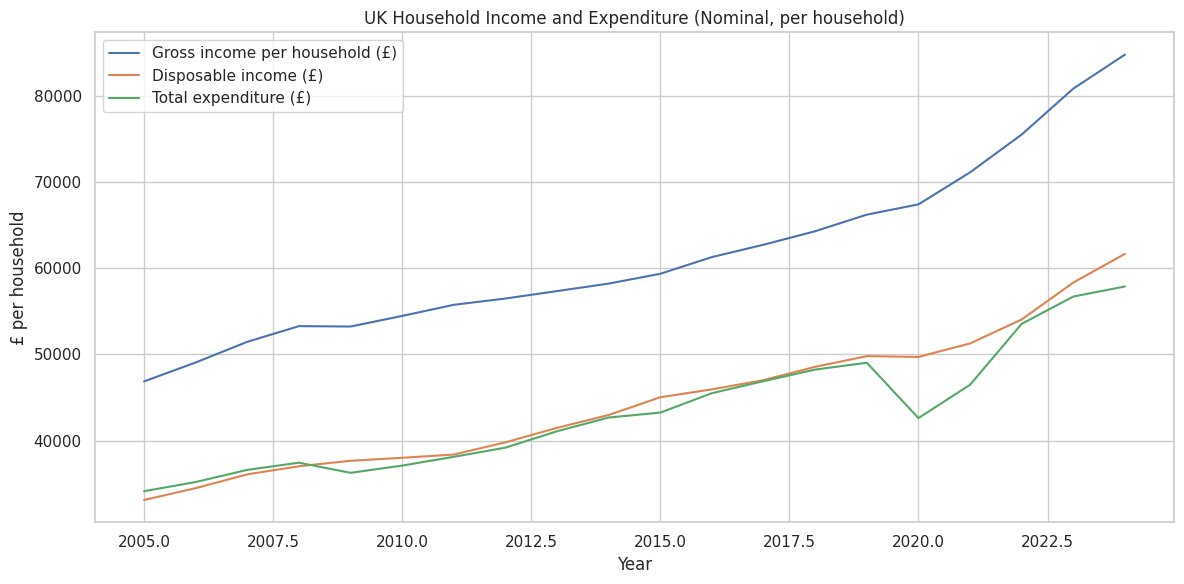

In [340]:
# Line chart: Nominal levels
plt.figure(figsize=(12,6))
plt.plot(general_household_view['year'], general_household_view['gross_earnings_per_household'], label="Gross income per household (£)")
plt.plot(general_household_view['year'], general_household_view['disposable_income_gbp'], label="Disposable income (£)")
plt.plot(general_household_view['year'], general_household_view['total_expenditure'], label="Total expenditure (£)")
plt.title("UK Household Income and Expenditure (Nominal, per household)")
plt.xlabel("Year")
plt.ylabel("£ per household")
plt.legend()
plt.tight_layout()
plt.show()

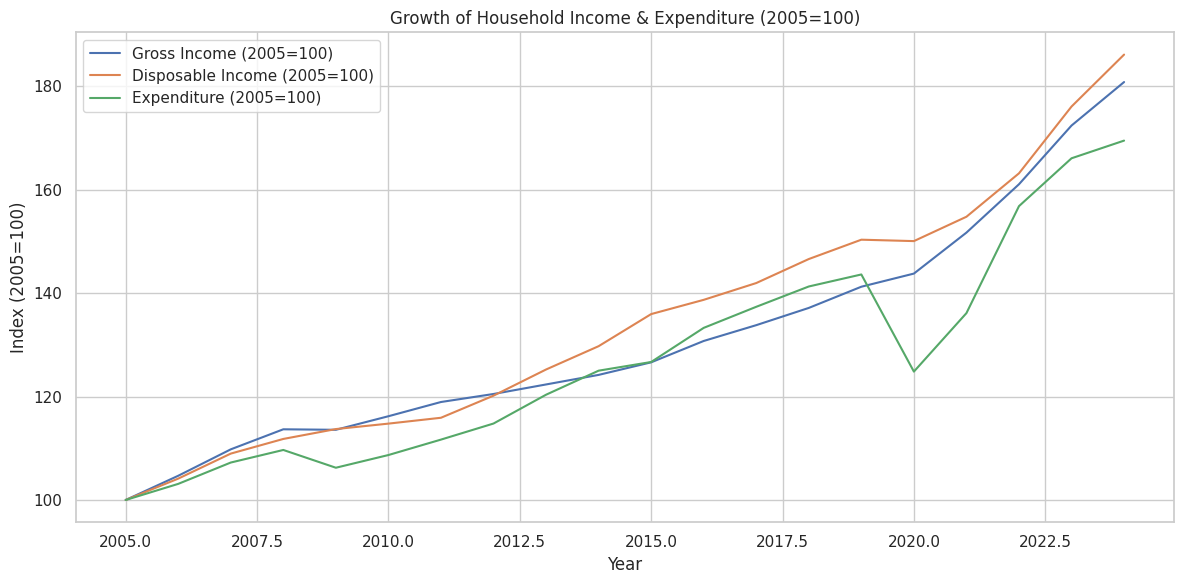

In [341]:
# Growth indices taking 2005 as the base year (2005 = 100)
base_year = 2005
df_indexed = general_household_view.set_index("year")

for col in ['gross_earnings_per_household','disposable_income_gbp','total_expenditure']:
    df_indexed[col+"_index"] = (df_indexed[col] / df_indexed.loc[base_year, col]) * 100

plt.figure(figsize=(12,6))
plt.plot(df_indexed.index, df_indexed['gross_earnings_per_household_index'], label="Gross Income (2005=100)")
plt.plot(df_indexed.index, df_indexed['disposable_income_gbp_index'], label="Disposable Income (2005=100)")
plt.plot(df_indexed.index, df_indexed['total_expenditure_index'], label="Expenditure (2005=100)")
plt.title("Growth of Household Income & Expenditure (2005=100)")
plt.xlabel("Year")
plt.ylabel("Index (2005=100)")
plt.legend()
plt.tight_layout()
plt.show()

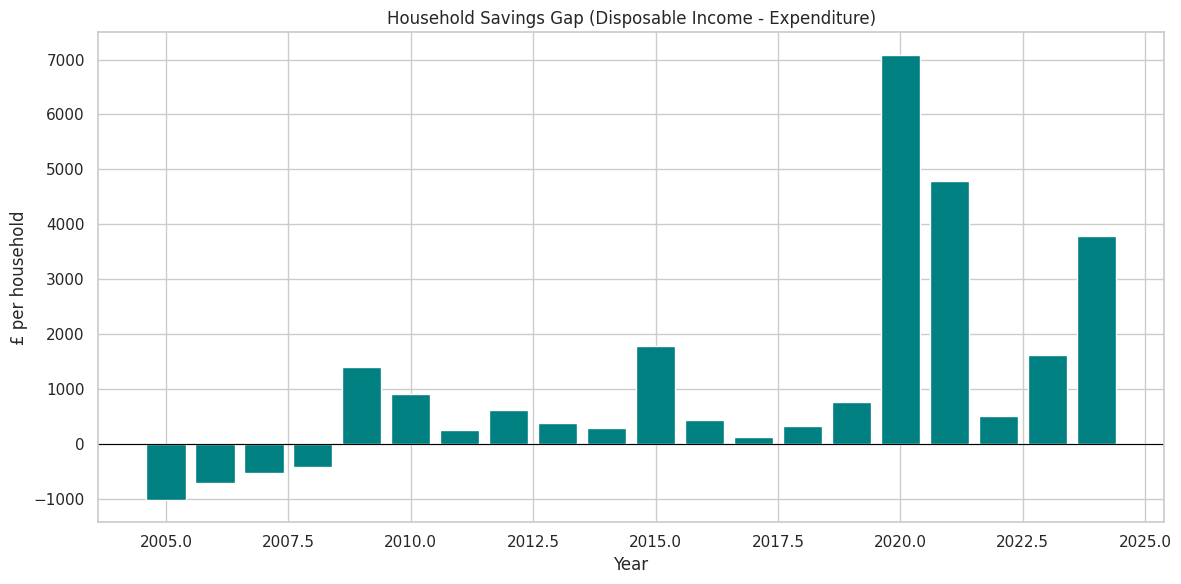

In [342]:
# 3. Savings gap (Disposable - Expenditure)
general_household_view['savings_gap'] = general_household_view['disposable_income_gbp'] - general_household_view['total_expenditure']

plt.figure(figsize=(12,6))
plt.bar(general_household_view['year'], general_household_view['savings_gap'], color="teal")
plt.axhline(0,color="black",linewidth=0.8)
plt.title("Household Savings Gap (Disposable Income - Expenditure)")
plt.xlabel("Year")
plt.ylabel("£ per household")
plt.tight_layout()
plt.show()